#### Notebook character counter:

In [63]:
import json

def count_chars(filename):
    with open(filename) as f:
        nb = json.load(f)
    
    counts = {'code': 0, 'markdown': 0, 'raw': 0, 'other': 0}
    
    for cell in nb['cells']:
        cell_type = cell['cell_type']
        chars = sum(len(line) for line in cell['source'])
        if cell_type in counts:
            counts[cell_type] += chars
        else:
            counts['other'] += chars
    
    total = sum(counts.values())
    
    for cell_type in ['code', 'markdown', 'raw', 'other']:
        print(f"{cell_type},{counts[cell_type]}")
    
    print(f"total,{total}")
    
    if total > 75000:
        print("Too many characters in assignment submission (> 75,000)")
    else:
        print("Number of characters ok ( < 75,000)")

count_chars('Task-1.ipynb')

code,4185
markdown,2792
raw,0
other,0
total,6977
Number of characters ok ( < 75,000)


## Table of Contents
1. [Introduction](#1-introduction)
2. [References](#2-references)
   1. [Python libraries used for assignment](#21-python-libraries-used-for-assignment)
3. [Setup and Initialization](#3-setup-and-initialization)
   1. [Load/Import the required Python libraries:](#31-loadimport-the-required-python-libraries)
   2. [Load the 3 datasets into individual pandas dataframes](#32-load-the-3-datasets-into-individual-pandas-dataframes)
   3. [Create Generic functions to be used by all datasets](#33-create-generic-functions-to-be-used-by-all-datasets)
4. [Evaluate Dataset 1](#4-evaluate-dataset-1)
   1. [Analyse the Data](#41-analyse-the-data)
      1. [Shape of the data](#411-shape-of-the-data)
      2. [Info of the data](#412-info-of-the-data)
      3. [Plot Bar Charts](#413-plot-bar-charts)
         1. [Standard Bar Chart](#standard-bar-chart)
         2. [Seaborn Bar Chart](#seaborn-bar-chart)
      4. [Identify Missing Data](#414-identify-missing-data)
      5. [Scatter Matrix](#415-scatter-matrix)


## 1. Introduction

## 2. References

The following references are useful for the purpose of this assignment.

### 2.1 Python libraries used for assignment:

As part of the assignment, I have used the below listed Python libraries:

1. pandas - Python Data Analytics Library
   
    - https://pandas.pydata.org/

2. numpy - Scientific computing with Python

    - https://numpy.org/

3. missingno - Visualising missing data in dataframes

    - https://github.com/ResidentMario/missingno

4. scikit-learn - Machine Learning Library for Python

    - https://scikit-learn.org/stable/

5. matplotlib - Visualisation with Python

    - https://matplotlib.org/

6. seaborn - Statistical data visualisation

    - https://seaborn.pydata.org/

## 3. Setup and Initialization:

### 3.1 Load/Import the required Python libraries:

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import time

# Data Visualization
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.pyplot import figure
from pandas.plotting import scatter_matrix

# ML Algorithms
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

# Evaluation Metrics
from sklearn.metrics import mean_squared_error, r2_score, classification_report, confusion_matrix

### 3.2 Load the 3 datasets into individual pandas dataframes

In [53]:
import pandas as pd

# Set the display precision to 2
pd.set_option('display.precision', 2)

# Load 3 datasets into individual panda dataframes for further processing
df1 = pd.read_csv('CML_2026-01-26#4-dataset_1.csv')
df2 = pd.read_csv('CML_2026-01-26#5-dataset_2.csv')
df3 = pd.read_csv('CML_2026-01-26#6-dataset_3.csv')

### 3.3 Create Generic functions to be used by all datasets

In [82]:
# Pandas tables display more neatly when precision is set to 2 decimal places.
pd.set_option('display.precision', 2)

def evaluate_model(model, X_train, X_test, Y_train, Y_test, model_name):
    # Calculate training time
    start_time = time.time()
    model.fit(X_train, Y_train)
    end_time = time.time()
    training_time = end_time - start_time
    
    # Calculate prediction time
    start_pred = time.time()
    Y_pred = model.predict(X_test)
    end_pred = time.time()
    prediction_time = end_pred - start_pred

    # Calculate evaluation metrics mean squared error and R^2 score
    mse = mean_squared_error(Y_test, Y_pred)
    r2 = r2_score(Y_test, Y_pred)
    
    # Print results
    print("------------ START ------------\n")
    print(f"Model: {model_name}")
    print(f"Training time: {training_time:.2f} seconds")
    print(f"Prediction time: {prediction_time:.2f} seconds")
    print("Classification Report:")
    #print(classification_report(Y_test, Y_pred))
    print("Confusion Matrix:")
    #print(confusion_matrix(Y_test, Y_pred))
    print(f"Mean Squared Error: {mse:.2f}")
    print(f"R^2 Score: {r2:.2f}")
    print("------------ END ------------\n")

    return Y_pred 

## 4. Evaluate Dataset 1:

### 4.1 Analyse the data:

#### 4.1.1 Shape of the data:

In [74]:
print(f"df1.shape = {df1.shape}")

df1.shape = (1001, 3)


#### 4.1.2 Info of the data:

In [75]:
print("df1.info =")
df1.info()

df1.info =
<class 'pandas.DataFrame'>
RangeIndex: 1001 entries, 0 to 1000
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   X         1001 non-null   int64   
 1   y         1001 non-null   float64 
 2   X_binned  1001 non-null   category
dtypes: category(1), float64(1), int64(1)
memory usage: 16.9 KB


#### 4.1.3 Plot Charts:
Because `X` is a continuos variable with over 1000 points, a standard bar chart would be over cluttered. Instead, we will divide the `X` values in equal sized bins and calculate the mean `Y` value for each bin.

##### Standard Bar Chart

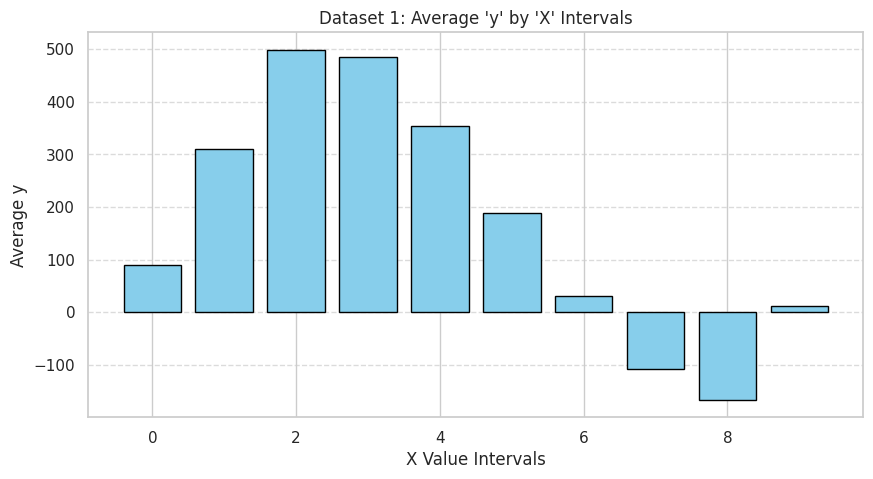

In [76]:
# 1. Group X into 10 equal-width bins
df1['X_binned'] = pd.cut(df1['X'], bins=10)

# 2. Calculate the average 'y' for each bin
binned_data = df1.groupby('X_binned')['y'].mean().reset_index()

# 3. Create the Bar Chart
plt.figure(figsize=(10, 5))
plt.bar(binned_data.index, binned_data['y'], color='skyblue', edgecolor='black')


plt.xlabel("X Value Intervals")
plt.ylabel("Average y")
plt.title("Dataset 1: Average 'y' by 'X' Intervals")

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

##### Seaborn Bar Chart

/tmp/ipykernel_105344/3461970842.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(bin_labels, rotation=45, ha='right')


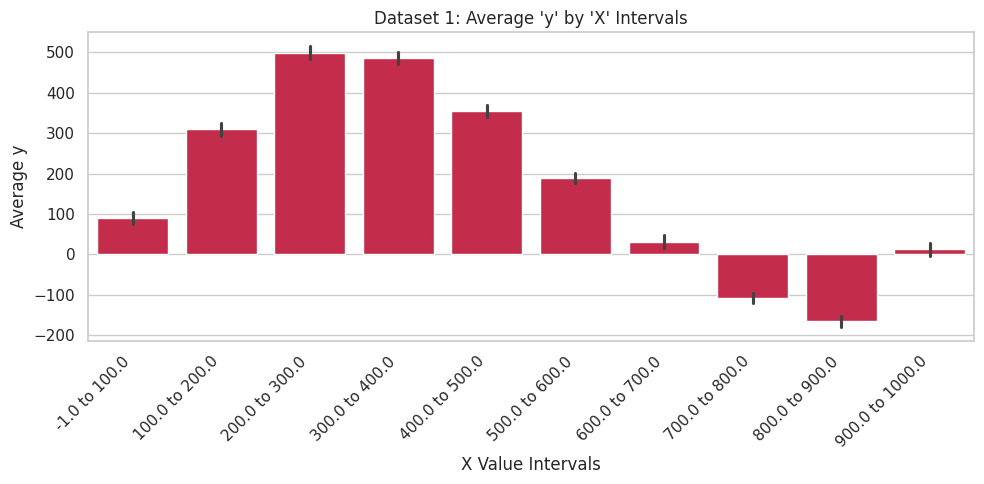

In [77]:
# 1. Group X into 10 equal-width bins
df1['X_binned'] = pd.cut(df1['X'], bins=10)

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 5))

ax = sns.barplot(
    data=df1, 
    x='X_binned', 
    y='y', 
    color='crimson',
    legend=False
)

bin_labels = [f"{interval.left:.1f} to {interval.right:.1f}" for interval in df1['X_binned'].cat.categories]
ax.set_xticklabels(bin_labels, rotation=45, ha='right')

plt.xlabel("X Value Intervals")
plt.ylabel("Average y")
plt.title("Dataset 1: Average 'y' by 'X' Intervals")

plt.tight_layout()
plt.show()

#### 4.1.4 Identify Missing Data:
It is always useful to identify any patterns in missing data.
`Missingno` is a useful library for visualising the missing data.

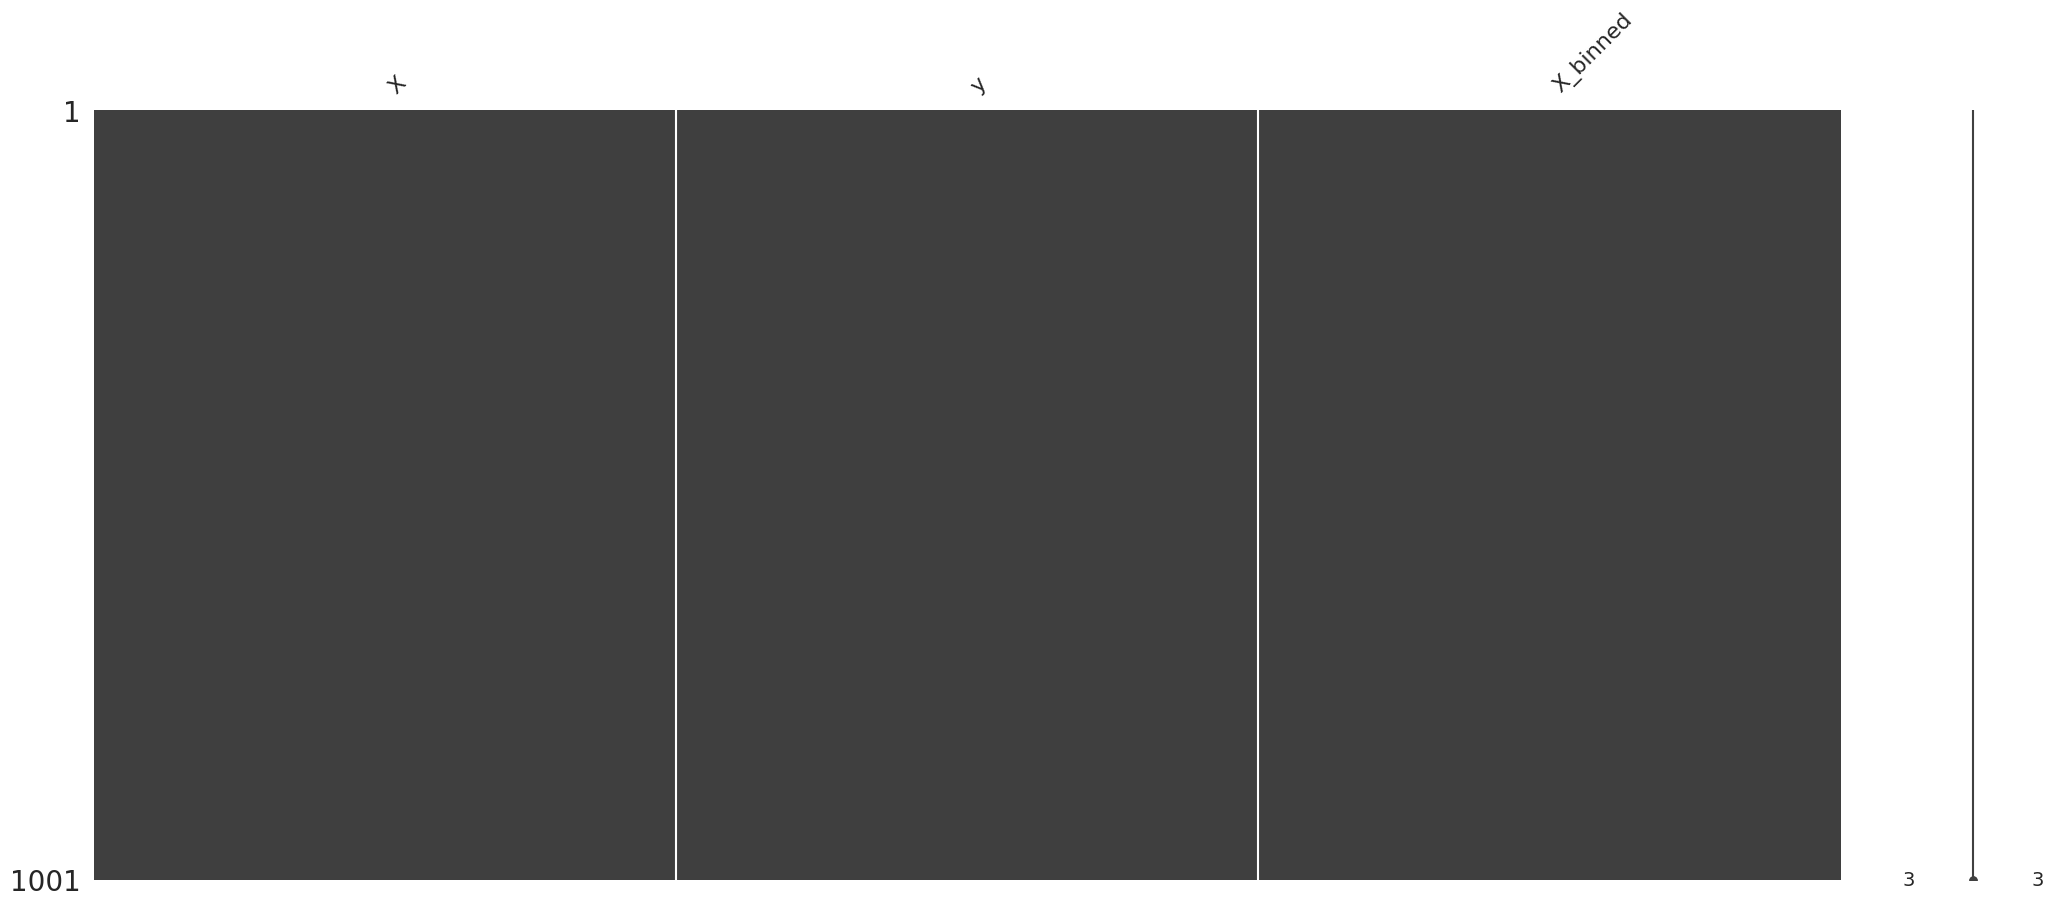

In [78]:
msno.matrix(df1)
plt.show()

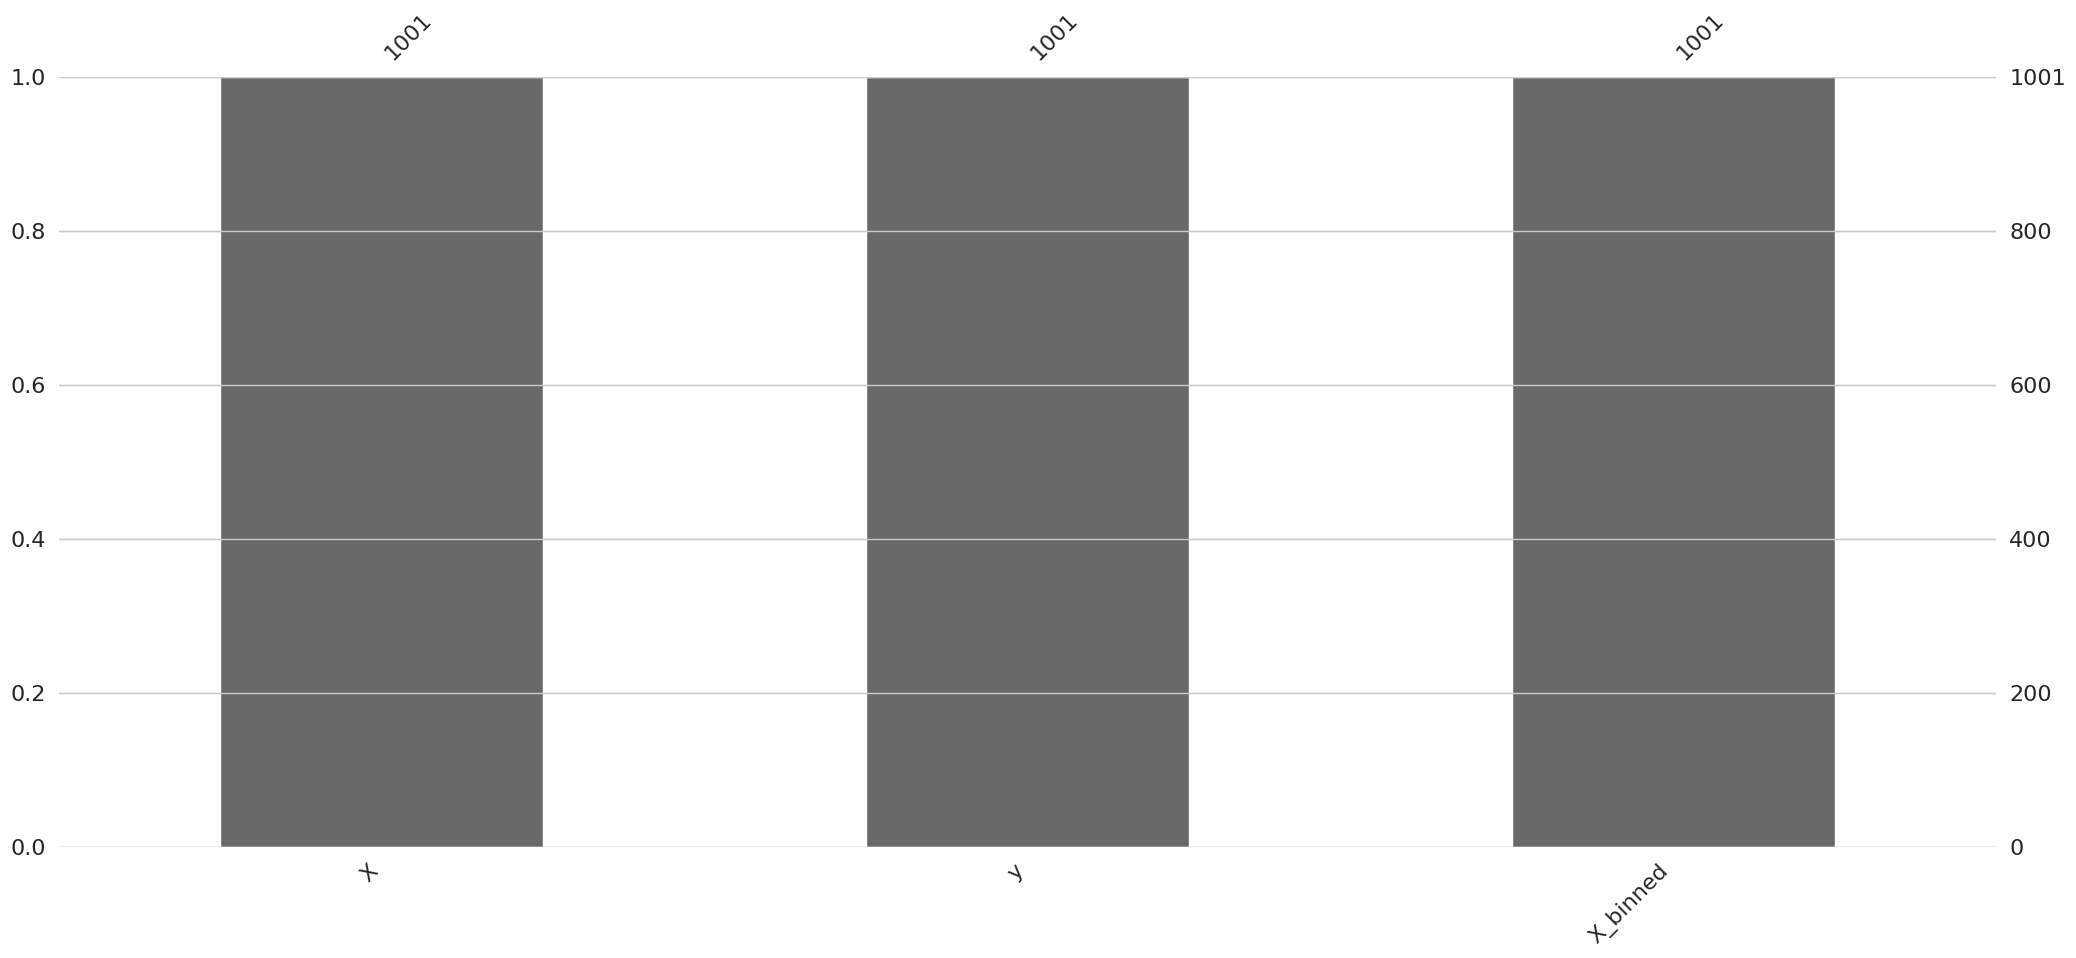

In [79]:
msno.bar(df1)
plt.show()

It is obvious from the above 2 plots that we do not have any missing data.

#### 4.1.5 Scatter Matrix:
Lets evaluate the relationship using the `scatter_matrix` funtion from `pandas.plotting`

Because we have one feature and one target, we can visualize the dataset perfectly in 2D space.

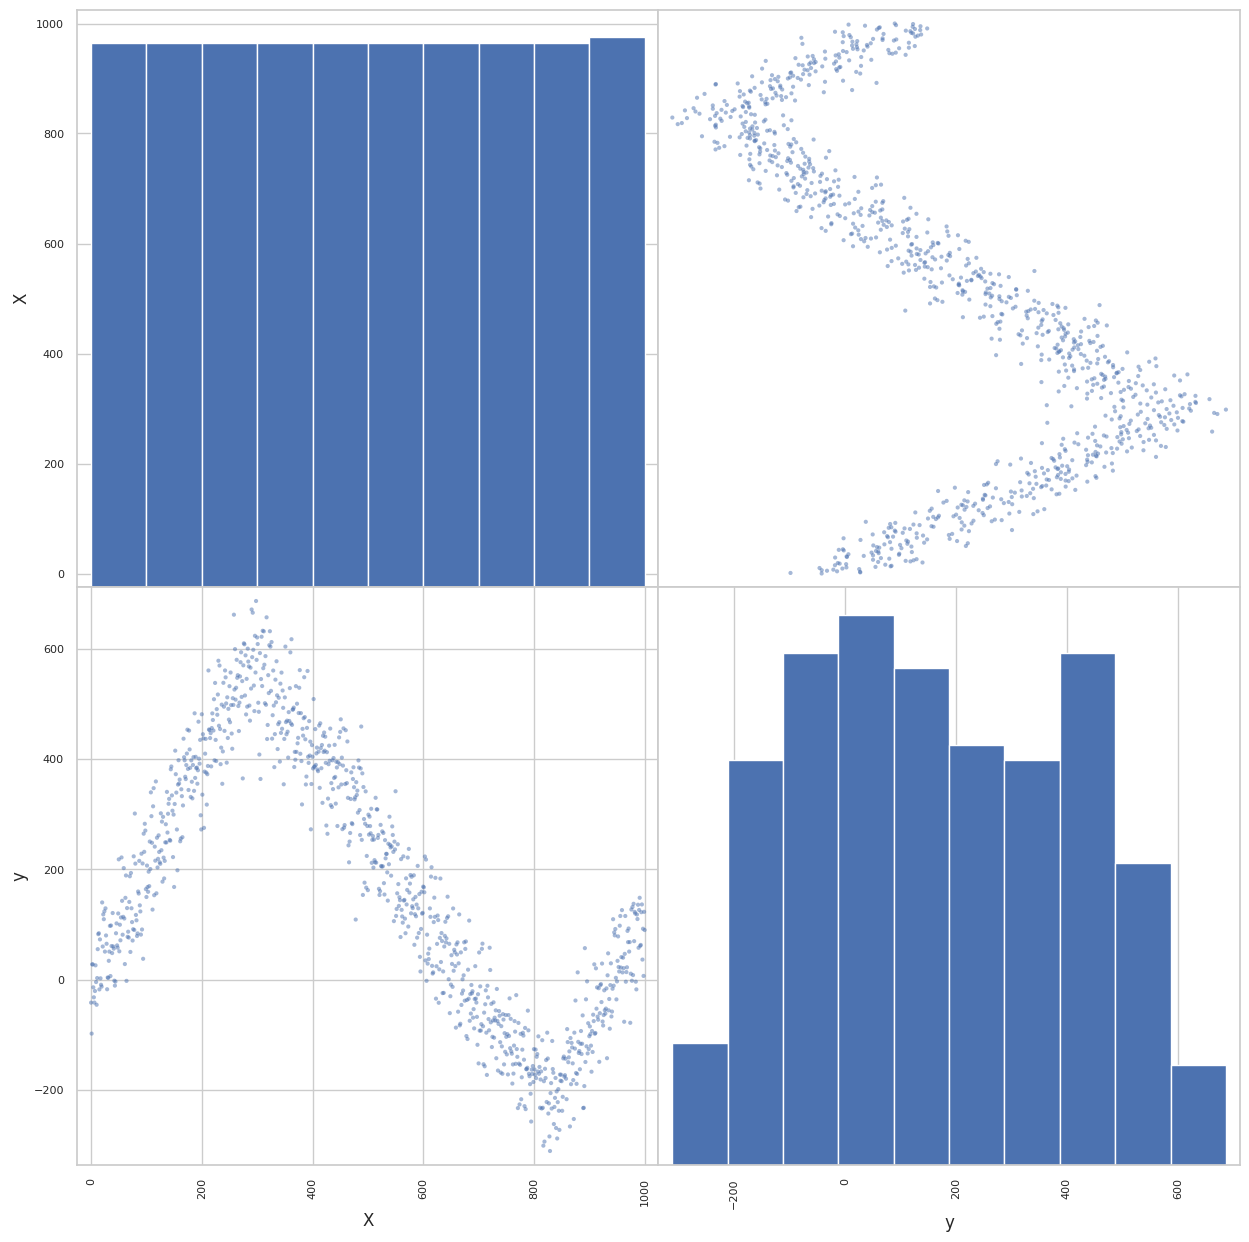

In [ ]:
scatter_matrix(df1, figsize=(15,15));

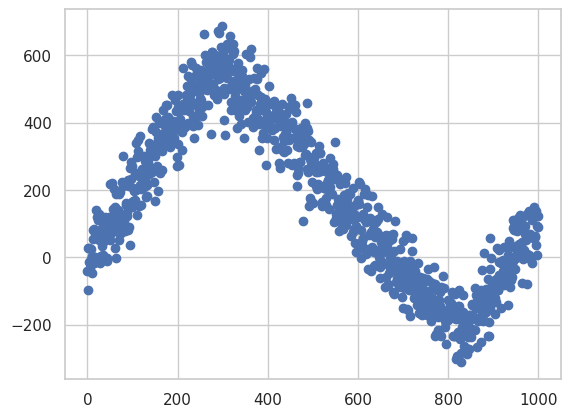

In [81]:
plt.scatter(df1['X'], df1['y'])

The above plot proves that the `relationship is non-linear` (U-Shaped) and `Linear Regression will fail` in this instance and something like a `Polynomial Regression will be required` for this dataset.

### 4.2 Analyse Models for the dataset

> **Note:** Since we have determined through analysis that the data is non-linear, U-shaped curve. We will use the below models to train with the dataset and find the best fit for the dataset.

<ins>Models to train and test:</ins>
- Linear Regression
- Polynomial Regression
- Random Forest

In [92]:
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import WhiteKernel, RBF, ConstantKernel

X1 = df1[['X']]
y1 = df1['y']
X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=0.2, random_state=42)

# 1. Linear Regression
lr1 = LinearRegression()
evaluate_model(lr1, X1_train, X1_test, y1_train, y1_test, "Linear Regression")

# 2. Polynomial Regression (Degree 3)
poly3 = make_pipeline(PolynomialFeatures(degree=3), LinearRegression())
evaluate_model(poly3, X1_train, X1_test, y1_train, y1_test, "Polynomial Regression (Deg 3)")

# 3. Random Forest
rf1 = RandomForestRegressor(random_state=42)
evaluate_model(rf1, X1_train, X1_test, y1_train, y1_test, "Random Forest")

# 4. Support Vector Regression
svr1 = SVR(kernel='rbf', C=1, gamma=1)
evaluate_model(svr1, X1_train, X1_test, y1_train, y1_test, "SVR")

# 5. Gaussian Process Regressor (Scaled)
# We define a kernel that handles scaling and noise
kernel1 = ConstantKernel(1.0, (1e-3, 1e3)) * RBF(1.0, (1e-2, 1e2)) + WhiteKernel(noise_level=1e-1)
gpr1 = make_pipeline(StandardScaler(), GaussianProcessRegressor(kernel=kernel1, random_state=42))
evaluate_model(gpr1, X1_train, X1_test, y1_train, y1_test, "Gaussian Process")

------------ START ------------

Model: Linear Regression
Training time: 0.00 seconds
Prediction time: 0.00 seconds
Classification Report:
Confusion Matrix:
Mean Squared Error: 35231.55
R^2 Score: 0.41
------------ END ------------

------------ START ------------

Model: Polynomial Regression (Deg 3)
Training time: 0.00 seconds
Prediction time: 0.00 seconds
Classification Report:
Confusion Matrix:
Mean Squared Error: 4500.11
R^2 Score: 0.92
------------ END ------------

------------ START ------------

Model: Random Forest
Training time: 0.17 seconds
Prediction time: 0.01 seconds
Classification Report:
Confusion Matrix:
Mean Squared Error: 4936.70
R^2 Score: 0.92
------------ END ------------

------------ START ------------

Model: SVR
Training time: 0.02 seconds
Prediction time: 0.01 seconds
Classification Report:
Confusion Matrix:
Mean Squared Error: 60799.12
R^2 Score: -0.02
------------ END ------------

------------ START ------------

Model: Gaussian Process
Training time: 5.0

/home/huzefar/Projects/oxford/CML/workspace/.venv/lib/python3.14/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


array([ 233.35883713,  -11.35088   , -108.3207122 ,   53.77276462,
        408.95038187,  -11.54680319,   -1.79910653,  245.97641592,
       -146.09989696,  271.26371348, -104.6624326 ,  134.57822683,
       -105.53379841, -166.07624419,  -15.03680548,  -86.43326191,
        513.26491086, -112.41217491,  154.78927182,  510.64565759,
        189.86253994,  361.18037193,  464.68176293,  223.95172123,
        435.2514545 ,  474.7988599 ,  188.59654023,   63.39848278,
        -81.22494462, -140.17006517,  491.73490456,  278.50534663,
         78.85203633,  268.25276291,  465.90549235,  412.45266526,
         31.9583186 ,  135.11161391, -140.27994156,  101.61687386,
        505.72265047,  177.34461809,  513.42524473,   46.43280571,
        515.98924849,  512.10493404,  -41.11250913,  109.37901796,
        365.09173279,    6.7507285 ,  -32.70874668, -118.33232617,
        502.49788614,   23.98483382,   44.11636756,   53.90864826,
         84.99359189,   27.74630798,  454.07879904,  -66.95398

### 4.3 Model Results for Dataset 1

| Model Name | Mean Squared Error | R^2 Score |
| ---------- | ------------------ | --------- |a
| Linear Regression | 35231.55 | 0.41 |
| Polynomial Regression (3rd Deg)| 4500.11 | 0.92 |
| Random Forest | 4936.70 | 0.92 |
| SVR | 60799.12 | -0.02 |
| Gaussian Process | 3565.31 | 0.94 |